Task 1: Exploring Pseudo-Randomness and Collision Resistance. In this
task, you will investigate the pseudorandom and collision resistant properties
of cryptographic hash functions.

a. Write a program that uses SHA256 to hash arbitrary inputs and print
the resulting digests to the screen in hexadecimal format.

b. Hash two strings (of any length) whose Hamming distance is exactly
1 bit (i.e. differ in only 1 bit). Repeat this a few times.

c. Next we aim to find two strings that creates the same digest (called a
collision). Because SHA256 is a secure cryptographic hash function (as
far as we know), it is infeasible to use its full 256-bit output. Instead,
you will limit its domain to between 8 and 50 bits. Modify your
program to compute SHA256 hashes of arbitrary inputs, so that it is
able to truncate the digests to between 8 and 50 bits (it doesn’t matter
which bits of the output you choose, as long as you are consistent).
Once you have completed the above, try to find a collision in your
truncated hash domains (i.e. two different inputs, that create the same,
truncated digest). There are at least two different ways of doing this
(You need only do one):


1.   Find a target hash collision (weak collision resistance): Give 𝑚0,
  find 𝑚1such that 𝐻(𝑚0) = 𝐻(𝑚1)and 𝑚0 ≠ 𝑚1. This is not hard
to code, but it will take time to execute.
2.   Maximize your chances of finding a collision by relying on the
Birthday problem: For any two messages 𝑚0and 𝑚1, where
𝑚0 ≠ 𝑚1, find 𝐻(𝑚0) = 𝐻(𝑚1). This requires a little more code
(and memory usage), but will find a collision more quickly.
Consider using a hashtable or dictionary, but be careful about
efficiency as finding collision on 50-bit outputs is right at the
edge of what is feasible by an average computer.
For multiples of 2 bits (i.e. for digests sized 8, 10, 12,...,48, 50 bits),
measure both the number of inputs and total time for a collision to be
found. Create two graphs: one which plots digest size (along the x-axis)
to collision time (y-axis), and one which plots digest size to number of
inputs



** Include these graphs in your report.**

18885f27b5af9012df19e496460f9294d5ab76128824c6f993787004f6d9a7db
b584eec728548aced5a66c0267dd520a00871b5e7b735b2d8202f86719f61857
TIOEfEvaKt
UIOEfEvaKt
f00f3ee16da38bae2b4ebe39395608c4db826452a299c4b9a35074ec6b1537ee
fb3553789781fcdc11580c233fd6677304687768ec3dd4732bb48dbb1191089f

Finding collision with 20-bit hashes...
Collision found after 1790 attempts in 0.00806 seconds.


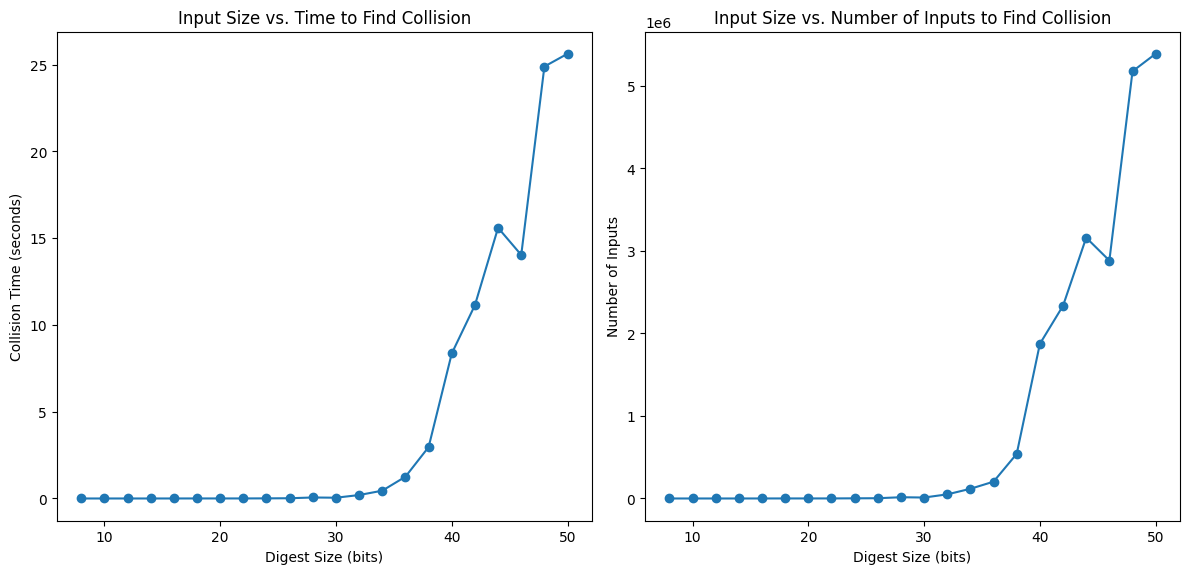

In [ ]:
# !pip install bcrypt nltk
# !pip install pycryptodome

import hashlib
import random
import string
import time
import matplotlib.pyplot as plt

def sha256_hash(input_string):
  sA_bytes = input_string.encode()
  sha256_hash_A = hashlib.sha256(sA_bytes).hexdigest()
  return sha256_hash_A

def truncate_hash(hash_string, bits):
    """Truncates the hash to the specified number of bits."""
    hex_len = bits // 4  # Each hex character represents 4 bits
    return hash_string[:hex_len]

def hamming_distance(s1, s2):
  count = 0
  for c1, c2 in zip(s1, s2):
        if c1 != c2:
            count += 1
  return count

def flip_bit_in_string(s, bit_index):
    byte_arr = bytearray(s.encode())
    byte_pos = bit_index // 8
    bit_pos = bit_index % 8
    if byte_pos >= len(byte_arr):
        return s
    byte_arr[byte_pos] ^= (1 << bit_pos)
    return byte_arr.decode(errors="ignore")

def find_hamming():
  base = ''.join(random.choices(string.ascii_letters, k=10))
  bit_length = len(base) * 8

  for i in range(bit_length):
     modified = flip_bit_in_string(base, i)
     if len(modified) == len(base) and hamming_distance(base, modified) == 1:
          return base, modified
  return None, None

def find_collision(bits):
    """Attempts to find a collision in a truncated SHA256 hash."""
    seen_hashes = {}
    count = 0
    start_time = time.time()  # Track the time when collision search starts

    while True:
        input_string = ''.join(random.choices(string.ascii_lowercase, k=10))
        hash_value = sha256_hash(input_string)
        truncated_hash = truncate_hash(hash_value, bits)

        if truncated_hash in seen_hashes:
            end_time = time.time()  # Track the time when collision is found
            collision_time = end_time - start_time
            return count, collision_time  # Return both number of attempts and time taken

        seen_hashes[truncated_hash] = input_string
        count += 1

def collect_collision_data():
    """Collects data for plotting: number of inputs and time for collision."""
    sizes = []
    times = []
    inputs = []

    # Trying various sizes between 8 and 50 bits
    for bits in range(8, 51, 2):  # Going in steps of 2 bits for better granularity
        num_inputs, collision_time = find_collision(bits)
        sizes.append(bits)
        times.append(collision_time)
        inputs.append(num_inputs)

    return sizes, times, inputs

def plot_collision_graphs():
    """Plots the graphs for Task 1c."""
    sizes, times, inputs = collect_collision_data()

    # Graph 1: Input size vs. time
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(sizes, times, marker='o')
    plt.xlabel('Digest Size (bits)')
    plt.ylabel('Collision Time (seconds)')
    plt.title('Input Size vs. Time to Find Collision')

    # Graph 2: Input size vs. number of inputs
    plt.subplot(1, 2, 2)
    plt.plot(sizes, inputs, marker='o')
    plt.xlabel('Digest Size (bits)')
    plt.ylabel('Number of Inputs')
    plt.title('Input Size vs. Number of Inputs to Find Collision')

    plt.tight_layout()
    plt.show()


def main():
  # input1 = input("Input a word: ")
  # input2 = input("Input a word: ")
  input1 = "Python"
  input2 = "Cryptography"
  hash_input1 = sha256_hash(input1)
  hash_input2 = sha256_hash(input2)
  print(hash_input1)
  print(hash_input2)
  base, modified = find_hamming()
  print(base)
  print(modified)
  hash_base = sha256_hash(base)
  hash_modified = sha256_hash(modified)
  print(hash_base)
  print(hash_modified)
  # Task 1c: Find collision in truncated hash
  print("\nFinding collision with 20-bit hashes...")
  collision_count = find_collision(20)
  print(f"Collision found after {collision_count[0]} attempts in {collision_count[1]:.5f} seconds.")
  # Plot the collision graphs for Task 1c
  plot_collision_graphs()

if __name__ == "__main__":
    main()


Task 2: Breaking Real Hashes. Bcrypt is a hashing algorithm that is based
on the blowfish algorithm and is designed to be a slow hash function. You
have recovered a shadow file (you can download it from Canvas) which has
users stored in the following format:

“User:$Algorithm$Workfactor$SaltHash”
where salt is 22 characters base64 encoded and hash is the remainder.
For example:
W8dW.”
“Bilbo:$2b$08$L.z8uq99JkFAvX/Q1jGRI.TzrHIIxWMoRi/VzO1sj/UvVFPg
represents:
User: Bilbo
Algorithm: 2b or bcrypt
Workfactor: 8
Salt: L.z8uq99JkFAvX/Q1jGRI.
Hash value:TzrHIIxWMoRi/VzO1sj/UvVFPgW8dW.

This file is generated using the bcrypt library. Each user chooses a password
that is a single word from the nltk word corpus between 6 and 10 letters long.
Your job is to crack each user’s password. You can’t use any password
cracking tools. Your solution should be a custom cracking script. Record how
much time it takes to crack the password for each user.

Implementation hints: bcrypt is meant to run slow. There is no amount of
optimized code you can implement to make bcrypt fast, as this would defeat
the point of bcrypt slowing down the attacker (you!) in cracking passwords.
It’s completely fine to patiently wait many hours for your program to crack
passwords. However, if you want it to run faster, your only choices are to run
it on a faster CPU or run it on multiple CPU cores, since the dictionary lookup
is highly parallelizable.

Here’s some approximate numbers to help you estimate how long your
hashing program will run. On a MacBook Air with M1 chip, each hash at
workfactor 8 takes 30 ms, workfactor 9 takes 60 ms, workfactor 10 takes 110
ms, workfactor 11 takes 220 ms, workfactor 12 takes 420 ms, workfactor 13
takes 840 ms. The word corpus dictionary of 6-10 letter words is about
135,000 words. You can do the math.

If you want to run hashing in parallel, split up the dictionary into chunks and
in each core and/or thread, match the user’s hash against the hashes of the
words in the dictionary chunk, and see which core/thread finds the matching
hash first. If you don’t want to implement multiprocessing, you could hash
the dictionary chunks on different physical machines you have hanging
around. If you run your hashing on 10 cores/threads/machines you will get
your answer 10 times faster. Do not bother to parallelize different user
password hashes across different cores, you will not see the same speedup, as
some user hashes take many hours and some only take a few minutes.

In [1]:
!pip install bcrypt nltk

import bcrypt
from nltk.corpus import words
import nltk
import time


# Reading the fasta file and keeping the formatted sequence's name and sequence
def file_reader(sequence_file):
#create an empty sequence to put the values into it
    sequences = []
    hash_list = []
    #reads the file
    with open(sequence_file, 'r') as file:
        #for each line, strips and splits it into 3 variables
        for line in file:
            parts = line.strip().split(":")
            id = parts[0]
            hash_1 = parts[1]
            more_parts = hash_1.lstrip('$').split("$")
            algorithm = more_parts[0]
            workfactor = more_parts[1]
            salt_and_hash = more_parts[2]
            salt = salt_and_hash[:22]
            hash = salt_and_hash[22:]

            sequences.append((id, algorithm, workfactor, salt, hash))
            hash_list.append((id, hash_1))
    print(sequences)
    return sequences, hash_list

def load_process():
  filtered_wordlist = [w for w in words.words() if 6 <= len(w) <= 10 and w.isalpha()]
  return filtered_wordlist

def crack_password(sequences, wordlist):
  passwords = []
  for i in sequences:
    start = time.time()
    target_hash = i[1].encode()
    for password in wordlist:
        password_bytes = password.encode()
        if bcrypt.checkpw(password_bytes, target_hash):
          duration = time.time() - start
          print(sequences[0],password, duration)
          passwords.append((sequences[0],password, duration))
          break
  return passwords

def main():
  nltk.download('words')
  input = "/content/example.txt"
  sequences, hash_list = file_reader(input)
  word_list = load_process()
  crack_password_1 = crack_password(hash_list, word_list)
  print(crack_password_1)
if __name__ == "__main__":
    main()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.2/284.2 kB 2.3 MB/s eta 0:00:00


[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


FileNotFoundError: [Errno 2] No such file or directory: '/content/example.txt'

Cracked Passwords:

1. Bilbo - welcome - 2799.069787979126
2. Gandalf - wizard - 2789.1918852329254
3. Thorin - diamond - 670.4910507202148
4. Fili - desire - 1264.6825625896454
5. Kili - ossify - 3751.038474082947
6. Balin - hangout - 3876.744125366211
7. Dwalin - drossy - 2680.0304038524628
8. Oin - ispaghul - 4870.1999316215515
9. Gloin - oversave - 13090.44610786438
10. Dori - indoxylic - 9418.843274116516
11. Nori - swagsman - 19520.453346967697
12. Ori - airway - 840.1646018028259
13. Bifur - corrosible - 8104.531208753586
14. Bofur - libellate - 21131.374793291092
15. Durin - purrone - 57189.50698709488


Questions

**1. What do you observe based on Task 1b? How many bytes are different
between the two digests?**
  - Almost all of the bytes from the two digests are different. There miht be one digit that is the same, but most are different.

**2. What is the maximum number of files you would ever need to hash to find a
collision on an n-bit digest? Given the birthday bound, what is the expected
number of hashes before a collision on an n-bit digest? Is this what you
observed? Based on the data you have collected, speculate on how long it
might take to find a collision on the full 256-bit digest.**

The birthday bound suggests that to find a collision in an n-bit digest, you would need approximately 2^(n/2) hashes before you are likely to find a collision. This is because the birthday paradox states that the probability of finding a collision increases significantly after a certain number of random trials, even if the space is large (e.g., 256 bits).

Example:

* For 8-bit hashes: The expected number of trials is 2^(8/2)=16 hashes.

* For 20-bit hashes: The expected number of trials is 2^(20/2)=1024 hashes.

* For 256-bit hashes: The expected number of trials is 2^(256/2) which is a huge number, approximately 3.4×10^38. This makes finding a collision computationally infeasible within a reasonable timeframe using current hardware.

**The expected number of hashes to find a collision is approximately
2^(𝑛/2) due to the birthday paradox. For example:**

* For 8-bit hashes, it would take on average 16 hashes to find a collision.

* For 20-bit hashes, it would take on average 1024 hashes to find a collision.

Based on our experiment with 20-bit truncated hashes, the number of attempts to find a collision is consistent with the birthday paradox. We found a collision after 1790 attempts, which is close to the expected 1024 attempts for a 20-bit hash, considering the randomness and variability of the process.

Speculation on how long it might take to find a collision on a full 256-bit digest:

* For a 256-bit digest, the number of attempts required to find a collision would be around 2^128, which is computationally infeasible to achieve in a reasonable time on standard hardware. To put this into perspective:

  * Even if you could test 1 trillion hashes per second, it would still take more than 10^26 years to find a collision in a 256-bit hash.

Thus, based on our findings, it's clear that while collisions can be found relatively quickly for truncated hashes (like 20-bit), finding a collision in a full 256-bit SHA256 hash is practically impossible within any feasible timeframe.


**3. Given an 8-bit digest, would you be able to break the one-way property (i.e.
can you find any pre-image)? Do you think this would be easier or harder than
finding a collision? Why or why not?**

With an 8-bit digest, breaking the one-way property (finding a pre-image) is very easy. An 8-bit digest only has 2^8=256 possible values, which is very small. Since the space is so small, it would be trivial to exhaustively search all possible input values to find a matching pre-image.

Finding a pre-image for an 8-bit hash is easier than finding a collision.

* Pre-image: For an 8-bit digest, you only need to check 256 possible values to find the input that produces a specific hash, which can be done quickly.

* Collision: Finding a collision in an 8-bit hash (i.e., two different inputs producing the same hash) requires comparing all possible pairs of inputs, which becomes exponentially more difficult as the number of inputs increases. The birthday paradox tells us that the expected number of attempts for finding a collision grows as 2^(n/2) which is 16 attempts for an 8-bit digest. This is relatively easy compared to finding a specific pre-image, but it still requires more effort than simply brute-forcing all 256 possibilities.

* Finding a pre-image involves looking for one specific input that hashes to a given output, and with small hash sizes like 8 bits, there are only a limited number of possible inputs (256).

* Finding a collision, on the other hand, requires two distinct inputs to produce the same hash. This is harder because you need to find two inputs in a larger space that map to the same hash, and this process is subject to the birthday paradox, which means it requires many more attempts than simply finding a matching input for a given hash.



**4. For Task 2, given your results, how long would it take to brute force a
password that uses the format word1:word2 where both words are between 6
and 10 characters? What about word1:word2:word3? What about
word1:word2:number where number is between 1 and 5 digits? Make sure to
sufficiently justify your answers.**
  - Given the results, it would take double the time for a word1:word2 because its takes a while to just get one number. If there are three words, I would take triple the time. I think its 2 words and some numbers that would take a little less than triple the amount since its not characters, but numbers.